# RQ1 Silent Lifecycle Order Table with Median Stage Durations

This notebook rebuilds the silent lifecycle-order patterns from `rq1_lifecycle_order_severity_table.ipynb` and adds median stage durations in days.

Scope for this notebook:

- Use the same source files and filtering rules as the lifecycle severity table.
- Keep rows with valid Fix, Release, and Disclosure dates.
- Exclude rows where `Release Date < Fix Date` as timestamp/tag-selection anomalies.
- Focus only on silent patterns `S1`, `S2`, and `S3` because report timestamps are not available yet.
- Report median gaps for `First -> Second`, `Second -> Third`, and the total `First -> Third` duration.


In [32]:
import pandas as pd
from pathlib import Path

In [33]:
FIX_RELEASE_PATH = Path('../../data/rq1/external_release_nvd/fix_releases_from_patch_data_local_server.csv')
NVD_PATH = Path('../../data/rq1/external_release_nvd/cve_NVD_disclosure_dates.csv')
LINKS_PATH = Path('../../data/rq1/corrected_resolved_links_v2.csv')
SEVERITY_PATH = Path('../../data/rq1/repo_with_severity.csv')

fix_release = pd.read_csv(FIX_RELEASE_PATH)
nvd = pd.read_csv(NVD_PATH)
links = pd.read_csv(LINKS_PATH)
severity = pd.read_csv(SEVERITY_PATH)

print('fix_release:', fix_release.shape, 'unique CVEs:', fix_release['CVE_ID'].nunique())
print('nvd:', nvd.shape, 'unique CVEs:', nvd['CVE_ID'].nunique())
print('links:', links.shape, 'unique CVEs:', links['CVE_ID'].nunique())
print('severity:', severity.shape, 'unique CVEs:', severity['CVE_ID'].nunique())

fix_release: (832, 6) unique CVEs: 832
nvd: (832, 2) unique CVEs: 832
links: (832, 5) unique CVEs: 832
severity: (832, 10) unique CVEs: 832


## Build Lifecycle Dataset

This follows the same event construction as the severity table: fix date from commit date, release date from oldest tag date, disclosure date from NVD published date, and reporting characteristic from link presence.

In [34]:
df = fix_release[fix_release['Oldest Tag Date'].astype(str).str.lower().ne('not found')].copy()

df['Fix Date'] = pd.to_datetime(df['Commit Date'], errors='coerce')
df['Release Date'] = pd.to_datetime(df['Oldest Tag Date'], errors='coerce')

df = df.merge(nvd[['CVE_ID', 'Published Date']], on='CVE_ID', how='left')
df['Disclosure Date'] = pd.to_datetime(df['Published Date'], errors='coerce')

df = df.merge(links[['CVE_ID', 'Link Presence']], on='CVE_ID', how='left')
df['Reporting characteristics'] = df['Link Presence'].map({
    'contains links': 'Transparent',
    'no links': 'Silent',
})

df = df.merge(severity[['CVE_ID', 'Severity']], on='CVE_ID', how='left')

event_df = df.dropna(subset=[
    'Fix Date',
    'Release Date',
    'Disclosure Date',
    'Reporting characteristics',
    'Severity',
]).copy()

release_before_fix_df = event_df[event_df['Release Date'] < event_df['Fix Date']].copy()
event_df = event_df[event_df['Release Date'] >= event_df['Fix Date']].copy()

print('Rows excluded because Release Date < Fix Date:', release_before_fix_df.shape[0])
print('Rows available for lifecycle order + severity table:', event_df.shape[0])
print('Unique CVEs:', event_df['CVE_ID'].nunique())

Rows excluded because Release Date < Fix Date: 15
Rows available for lifecycle order + severity table: 743
Unique CVEs: 743


In [35]:
def order_events(row):
    events = [
        ('Fix', row['Fix Date']),
        ('Release', row['Release Date']),
        ('Disclosure', row['Disclosure Date']),
    ]

    tie_breaker = {
        'Fix': 0,
        'Release': 1,
        'Disclosure': 2,
    }

    ordered = sorted(events, key=lambda item: (item[1], tie_breaker[item[0]]))
    ordered_names = [name for name, _ in ordered]

    if row['Reporting characteristics'] == 'Transparent':
        return ['Report'] + ordered_names

    return ordered_names + ['None']


ordered_columns = event_df.apply(order_events, axis=1, result_type='expand')
ordered_columns.columns = ['First', 'Second', 'Third', 'Fourth']

order_df = pd.concat([
    event_df[['CVE_ID', 'PATCH', 'Reporting characteristics', 'Severity', 'Fix Date', 'Release Date', 'Disclosure Date']].reset_index(drop=True),
    ordered_columns.reset_index(drop=True),
], axis=1)

pattern_ids = {
    ('Silent', 'Fix', 'Release', 'Disclosure', 'None'): 'S1',
    ('Silent', 'Fix', 'Disclosure', 'Release', 'None'): 'S2',
    ('Silent', 'Disclosure', 'Fix', 'Release', 'None'): 'S3',
    ('Transparent', 'Report', 'Fix', 'Release', 'Disclosure'): 'T1',
    ('Transparent', 'Report', 'Fix', 'Disclosure', 'Release'): 'T2',
    ('Transparent', 'Report', 'Disclosure', 'Fix', 'Release'): 'T3',
}

order_df['Pattern'] = order_df.apply(
    lambda row: pattern_ids.get((
        row['Reporting characteristics'],
        row['First'],
        row['Second'],
        row['Third'],
        row['Fourth'],
    )),
    axis=1,
)

order_df['Pattern'].value_counts(dropna=False)

Pattern
T1    323
S1    258
T2     77
S2     38
T3     28
S3     19
Name: count, dtype: int64

## Silent Pattern Median Stage Durations

For each silent pattern, the duration columns below are computed using the actual event represented by each stage:

- `Median days: First -> Second`
- `Median days: Second -> Third`
- `Median days: First -> Third`


In [36]:
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']


def format_severity_distribution(values):
    counts = values.value_counts(dropna=False).to_dict()
    parts = []

    for severity_label in severity_order:
        count = int(counts.get(severity_label, 0))
        if severity_label == 'Unknown':
            if count > 0:
                parts.append(f'{severity_label} ({count})')
        else:
            parts.append(f'{severity_label} ({count})')

    for severity_label, count in sorted(counts.items()):
        if severity_label not in severity_order:
            parts.append(f'{severity_label} ({int(count)})')

    return ', '.join(parts)


def date_for_event(row, event_name):
    return row[f'{event_name} Date']


silent_order_df = order_df[order_df['Pattern'].isin(['S1', 'S2', 'S3'])].copy()

silent_order_df['First Date'] = silent_order_df.apply(lambda row: date_for_event(row, row['First']), axis=1)
silent_order_df['Second Date'] = silent_order_df.apply(lambda row: date_for_event(row, row['Second']), axis=1)
silent_order_df['Third Date'] = silent_order_df.apply(lambda row: date_for_event(row, row['Third']), axis=1)

silent_order_df['Days: First -> Second'] = (
    silent_order_df['Second Date'] - silent_order_df['First Date']
).dt.total_seconds() / 86400

silent_order_df['Days: Second -> Third'] = (
    silent_order_df['Third Date'] - silent_order_df['Second Date']
).dt.total_seconds() / 86400

silent_order_df['Days: First -> Third'] = (
    silent_order_df['Third Date'] - silent_order_df['First Date']
).dt.total_seconds() / 86400

silent_timing_table = (
    silent_order_df
    .groupby(['Reporting characteristics', 'Pattern', 'First', 'Second', 'Third', 'Fourth'])
    .agg(
        Count=('CVE_ID', 'count'),
        **{
            'Median days: First -> Second': ('Days: First -> Second', 'median'),
            'Median days: Second -> Third': ('Days: Second -> Third', 'median'),
            'Median days: First -> Third': ('Days: First -> Third', 'median'),
            'Severity distribution': ('Severity', format_severity_distribution),
        }
    )
    .reset_index()
)

silent_timing_table['%'] = (
    silent_timing_table['Count']
    / silent_timing_table.groupby('Reporting characteristics')['Count'].transform('sum')
    * 100
).round(2)

duration_columns = [
    'Median days: First -> Second',
    'Median days: Second -> Third',
    'Median days: First -> Third',
]
silent_timing_table[duration_columns] = silent_timing_table[duration_columns].round(2)

silent_timing_table = silent_timing_table[
    [
        'Reporting characteristics',
        'Pattern',
        'First',
        'Second',
        'Third',
        'Fourth',
        'Count',
        '%',
        'Median days: First -> Second',
        'Median days: Second -> Third',
        'Median days: First -> Third',
        'Severity distribution',
    ]
]

silent_timing_table

,Reporting characteristics,Pattern,First,Second,Third,Fourth,Count,%,Median days: First -> Second,Median days: Second -> Third,Median days: First -> Third,Severity distribution
0,Silent,S1,Fix,Release,Disclosure,None,258,81.90,6.65,29.86,49.08,"Critical (6), High (38), Medium (202), Low (11..."
1,Silent,S2,Fix,Disclosure,Release,None,38,12.06,19.98,46.45,90.15,"Critical (1), High (7), Medium (28), Low (2)"
2,Silent,S3,Disclosure,Fix,Release,None,19,6.03,17.01,10.90,26.70,"Critical (1), High (0), Medium (17), Low (1)"


## Interpretation Helper

- `S1`: median `Fix -> Release` time and median `Release -> Disclosure` time.
- `S2`: median `Fix -> Disclosure` time and median `Disclosure -> Release` time.
- `S3`: median `Disclosure -> Fix` time and median `Fix -> Release` time.

No output is saved by default.

In [37]:
# Save nothing by default. Uncomment if needed.
# silent_timing_table.to_csv('rq1_silent_lifecycle_stage_medians.csv', index=False)

## Separate Table: Median and IQR

This table keeps the same silent patterns, but reports each duration as `median [Q1, Q3]` days. The bracketed values are the interquartile range bounds, not confidence intervals.

In [38]:
def median_iqr_text(values):
    values = values.dropna()
    median = values.median()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    return f'{median:.2f} [{q1:.2f}, {q3:.2f}]'


silent_timing_iqr_table = (
    silent_order_df
    .groupby(['Reporting characteristics', 'Pattern', 'First', 'Second', 'Third', 'Fourth'])
    .agg(
        Count=('CVE_ID', 'count'),
        **{
            'First -> Second days, median [IQR]': ('Days: First -> Second', median_iqr_text),
            'Second -> Third days, median [IQR]': ('Days: Second -> Third', median_iqr_text),
            'First -> Third days, median [IQR]': ('Days: First -> Third', median_iqr_text),
            'Severity distribution': ('Severity', format_severity_distribution),
        }
    )
    .reset_index()
)

silent_timing_iqr_table['%'] = (
    silent_timing_iqr_table['Count']
    / silent_timing_iqr_table.groupby('Reporting characteristics')['Count'].transform('sum')
    * 100
).round(2)

silent_timing_iqr_table = silent_timing_iqr_table[
    [
        'Reporting characteristics',
        'Pattern',
        'First',
        'Second',
        'Third',
        'Fourth',
        'Count',
        '%',
        'First -> Second days, median [IQR]',
        'Second -> Third days, median [IQR]',
        'First -> Third days, median [IQR]',
        'Severity distribution',
    ]
]

silent_timing_iqr_table

,Reporting characteristics,Pattern,First,Second,Third,Fourth,Count,%,"First -> Second days, median [IQR]","Second -> Third days, median [IQR]","First -> Third days, median [IQR]",Severity distribution
0,Silent,S1,Fix,Release,Disclosure,None,258,81.90,"6.65 [0.90, 27.05]","29.86 [8.13, 188.71]","49.08 [17.45, 227.93]","Critical (6), High (38), Medium (202), Low (11..."
1,Silent,S2,Fix,Disclosure,Release,None,38,12.06,"19.98 [6.86, 69.33]","46.45 [18.31, 196.63]","90.15 [49.14, 250.01]","Critical (1), High (7), Medium (28), Low (2)"
2,Silent,S3,Disclosure,Fix,Release,None,19,6.03,"17.01 [3.14, 31.18]","10.90 [1.21, 31.65]","26.70 [16.48, 113.32]","Critical (1), High (0), Medium (17), Low (1)"


## Separate Table: Severity-Wise Median and IQR

This table breaks timing down by both silent lifecycle pattern and CVE severity. Use the `Count` column carefully because some severity groups have small sample sizes.

In [39]:
silent_severity_timing_table = (
    silent_order_df
    .groupby(['Reporting characteristics', 'Pattern', 'Severity', 'First', 'Second', 'Third', 'Fourth'])
    .agg(
        Count=('CVE_ID', 'count'),
        **{
            'First -> Second days, median [IQR]': ('Days: First -> Second', median_iqr_text),
            'Second -> Third days, median [IQR]': ('Days: Second -> Third', median_iqr_text),
            'First -> Third days, median [IQR]': ('Days: First -> Third', median_iqr_text),
        }
    )
    .reset_index()
)

silent_severity_timing_table['Pattern total'] = silent_severity_timing_table.groupby('Pattern')['Count'].transform('sum')
silent_severity_timing_table['Within-pattern %'] = (
    silent_severity_timing_table['Count']
    / silent_severity_timing_table['Pattern total']
    * 100
).round(2)

severity_rank = {severity: index for index, severity in enumerate(severity_order)}
silent_severity_timing_table['Severity rank'] = silent_severity_timing_table['Severity'].map(severity_rank).fillna(99)

silent_severity_timing_table = (
    silent_severity_timing_table
    .sort_values(['Pattern', 'Severity rank'])
    .drop(columns=['Pattern total', 'Severity rank'])
)

silent_severity_timing_table = silent_severity_timing_table[
    [
        'Reporting characteristics',
        'Pattern',
        'Severity',
        'First',
        'Second',
        'Third',
        'Fourth',
        'Count',
        'Within-pattern %',
        'First -> Second days, median [IQR]',
        'Second -> Third days, median [IQR]',
        'First -> Third days, median [IQR]',
    ]
]

silent_severity_timing_table

,Reporting characteristics,Pattern,Severity,First,Second,Third,Fourth,Count,Within-pattern %,"First -> Second days, median [IQR]","Second -> Third days, median [IQR]","First -> Third days, median [IQR]"
0,Silent,S1,Critical,Fix,Release,Disclosure,None,6,2.33,"8.10 [1.65, 10.62]","8.26 [7.02, 32.54]","15.35 [9.28, 83.91]"
1,Silent,S1,High,Fix,Release,Disclosure,None,38,14.73,"2.78 [0.20, 21.89]","35.32 [11.82, 236.92]","47.68 [19.24, 299.86]"
3,Silent,S1,Medium,Fix,Release,Disclosure,None,202,78.29,"6.99 [1.12, 28.54]","29.86 [6.82, 168.49]","54.16 [18.32, 218.56]"
2,Silent,S1,Low,Fix,Release,Disclosure,None,11,4.26,"7.08 [2.77, 11.47]","16.39 [12.30, 57.81]","21.23 [15.99, 63.60]"
4,Silent,S1,Unknown,Fix,Release,Disclosure,None,1,0.39,"0.03 [0.03, 0.03]","795.43 [795.43, 795.43]","795.46 [795.46, 795.46]"
5,Silent,S2,Critical,Fix,Disclosure,Release,None,1,2.63,"3.39 [3.39, 3.39]","104.55 [104.55, 104.55]","107.93 [107.93, 107.93]"
6,Silent,S2,High,Fix,Disclosure,Release,None,7,18.42,"6.52 [3.04, 13.46]","56.93 [19.53, 193.90]","77.49 [32.74, 196.93]"
8,Silent,S2,Medium,Fix,Disclosure,Release,None,28,73.68,"38.53 [12.16, 79.94]","47.36 [21.88, 210.81]","109.12 [61.44, 289.51]"
7,Silent,S2,Low,Fix,Disclosure,Release,None,2,5.26,"10.19 [8.08, 12.29]","11.58 [8.39, 14.76]","21.76 [16.47, 27.06]"
9,Silent,S3,Critical,Disclosure,Fix,Release,None,1,5.26,"8.39 [8.39, 8.39]","1.25 [1.25, 1.25]","9.64 [9.64, 9.64]"


## Compact Severity Comparison View

This optional view keeps only pattern, severity, count, and total lifecycle duration. It is useful for quickly comparing whether total median duration changes across severity levels.

In [40]:
silent_severity_total_duration_view = silent_severity_timing_table[
    [
        'Pattern',
        'Severity',
        'Count',
        'Within-pattern %',
        'First -> Third days, median [IQR]',
    ]
].copy()

silent_severity_total_duration_view

,Pattern,Severity,Count,Within-pattern %,"First -> Third days, median [IQR]"
0,S1,Critical,6,2.33,"15.35 [9.28, 83.91]"
1,S1,High,38,14.73,"47.68 [19.24, 299.86]"
3,S1,Medium,202,78.29,"54.16 [18.32, 218.56]"
2,S1,Low,11,4.26,"21.23 [15.99, 63.60]"
4,S1,Unknown,1,0.39,"795.46 [795.46, 795.46]"
5,S2,Critical,1,2.63,"107.93 [107.93, 107.93]"
6,S2,High,7,18.42,"77.49 [32.74, 196.93]"
8,S2,Medium,28,73.68,"109.12 [61.44, 289.51]"
7,S2,Low,2,5.26,"21.76 [16.47, 27.06]"
9,S3,Critical,1,5.26,"9.64 [9.64, 9.64]"


## Grouped Stage View: Severity-Wise Timing

This view keeps the lifecycle stages as the main columns. The timing is written inside the stage cells, so each severity group can be read from left to right as a lifecycle sequence.

In [41]:
silent_severity_grouped_stage_view = silent_severity_timing_table.copy()

silent_severity_grouped_stage_view['First stage'] = silent_severity_grouped_stage_view['First']

silent_severity_grouped_stage_view['Second stage'] = (
    silent_severity_grouped_stage_view['Second']
    + '\nmedian from First: '
    + silent_severity_grouped_stage_view['First -> Second days, median [IQR]']
    + ' days'
)

silent_severity_grouped_stage_view['Third stage'] = (
    silent_severity_grouped_stage_view['Third']
    + '\nmedian from Second: '
    + silent_severity_grouped_stage_view['Second -> Third days, median [IQR]']
    + ' days'
    + '\nmedian from First: '
    + silent_severity_grouped_stage_view['First -> Third days, median [IQR]']
    + ' days'
)

silent_severity_grouped_stage_view['Fourth stage'] = silent_severity_grouped_stage_view['Fourth']

silent_severity_grouped_stage_view = silent_severity_grouped_stage_view[
    [
        'Reporting characteristics',
        'Pattern',
        'Severity',
        'Count',
        'Within-pattern %',
        'First stage',
        'Second stage',
        'Third stage',
        'Fourth stage',
    ]
]

silent_severity_grouped_stage_view = silent_severity_grouped_stage_view.set_index([
    'Reporting characteristics',
    'Pattern',
    'Severity',
])

silent_severity_grouped_stage_view.style.set_properties(**{'white-space': 'pre-wrap', 'text-align': 'left'})

## Reader-Friendly Grouped View

This view separates the table by lifecycle pattern. Within each pattern, rows show severity levels and columns show the lifecycle stages. Timing is placed under the stage it leads into, which makes the table easier to read than a long flat dataframe.

In [42]:
def build_reader_friendly_stage_view(pattern):
    pattern_df = silent_severity_timing_table[
        silent_severity_timing_table['Pattern'].eq(pattern)
    ].copy()

    view = pd.DataFrame({
        ('Severity group', 'Severity'): pattern_df['Severity'].values,
        ('Severity group', 'n'): pattern_df['Count'].values,
        ('Severity group', '% within pattern'): pattern_df['Within-pattern %'].values,
        ('First', 'Stage'): pattern_df['First'].values,
        ('Second', 'Stage'): pattern_df['Second'].values,
        ('Second', 'Days from First\nmedian [IQR]'): pattern_df['First -> Second days, median [IQR]'].values,
        ('Third', 'Stage'): pattern_df['Third'].values,
        ('Third', 'Days from Second\nmedian [IQR]'): pattern_df['Second -> Third days, median [IQR]'].values,
        ('Third', 'Total days from First\nmedian [IQR]'): pattern_df['First -> Third days, median [IQR]'].values,
        ('Fourth', 'Stage'): pattern_df['Fourth'].values,
    })

    view.columns = pd.MultiIndex.from_tuples(view.columns)
    return view


silent_reader_friendly_stage_views = {
    pattern: build_reader_friendly_stage_view(pattern)
    for pattern in ['S1', 'S2', 'S3']
}

silent_reader_friendly_stage_view = pd.concat(
    silent_reader_friendly_stage_views,
    names=['Pattern', 'Row'],
)

silent_reader_friendly_stage_view = silent_reader_friendly_stage_view.droplevel('Row')

silent_reader_friendly_stage_view

Severity group                             First      Second  \
              Severity    n % within pattern       Stage       Stage   
Pattern                                                                
S1            Critical    6             2.33         Fix     Release   
S1                High   38            14.73         Fix     Release   
S1              Medium  202            78.29         Fix     Release   
S1                 Low   11             4.26         Fix     Release   
S1             Unknown    1             0.39         Fix     Release   
S2            Critical    1             2.63         Fix  Disclosure   
S2                High    7            18.42         Fix  Disclosure   
S2              Medium   28            73.68         Fix  Disclosure   
S2                 Low    2             5.26         Fix  Disclosure   
S3            Critical    1             5.26  Disclosure         Fix   
S3              Medium   17            89.47  Disclosure         Fix   
S3                 Low    1             5.26  Disclosure         Fix   

                                            Third  \
        Days from First\nmedian [IQR]       Stage   
Pattern                                             
S1                 8.10 [1.65, 10.62]  Disclosure   
S1                 2.78 [0.20, 21.89]  Disclosure   
S1                 6.99 [1.12, 28.54]  Disclosure   
S1                 7.08 [2.77, 11.47]  Disclosure   
S1                  0.03 [0.03, 0.03]  Disclosure   
S2                  3.39 [3.39, 3.39]     Release   
S2                 6.52 [3.04, 13.46]     Release   
S2               38.53 [12.16, 79.94]     Release   
S2                10.19 [8.08, 12.29]     Release   
S3                  8.39 [8.39, 8.39]     Release   
S3                20.90 [4.45, 35.70]     Release   
S3                  0.49 [0.49, 0.49]     Release   

                                                                            \
        Days from Second\nmedian [IQR] Total days from First\nmedian [IQR]   
Pattern                                                                      
S1                  8.26 [7.02, 32.54]                 15.35 [9.28, 83.91]   
S1               35.32 [11.82, 236.92]               47.68 [19.24, 299.86]   
S1                29.86 [6.82, 168.49]               54.16 [18.32, 218.56]   
S1                16.39 [12.30, 57.81]                21.23 [15.99, 63.60]   
S1             795.43 [795.43, 795.43]             795.46 [795.46, 795.46]   
S2             104.55 [104.55, 104.55]             107.93 [107.93, 107.93]   
S2               56.93 [19.53, 193.90]               77.49 [32.74, 196.93]   
S2               47.36 [21.88, 210.81]              109.12 [61.44, 289.51]   
S2                 11.58 [8.39, 14.76]                21.76 [16.47, 27.06]   
S3                   1.25 [1.25, 1.25]                   9.64 [9.64, 9.64]   
S3                 14.84 [1.87, 43.82]               31.60 [21.32, 115.41]   
S3                   0.15 [0.15, 0.15]                   0.64 [0.64, 0.64]   

        Fourth  
         Stage  
Pattern         
S1        None  
S1        None  
S1        None  
S1        None  
S1        None  
S2        None  
S2        None  
S2        None  
S2        None  
S3        None  
S3        None  
S3        None

## Visual: Stage-Aligned Boxplots with Rounded Local Axes

This version keeps the boxes wide and boxplot-like while using local transition axes to show early versus late timing. Each transition axis starts at 0 and uses tick marks in multiples of 10. The plotted axis maximum is based on Q3/median summaries rather than extreme raw outliers, so the boxes remain readable.


Excluded from visual because n < 2:


,Pattern,Severity,n
0,S1,Unknown,1
1,S2,Critical,1
2,S3,Critical,1
3,S3,Low,1


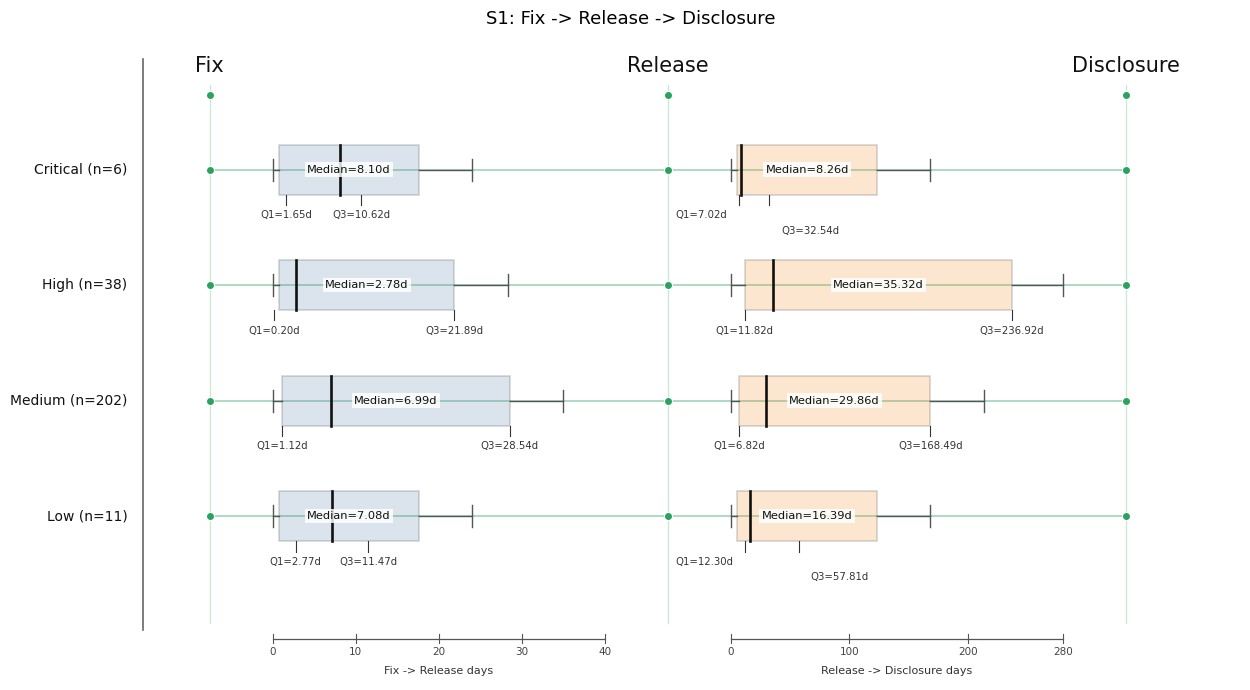

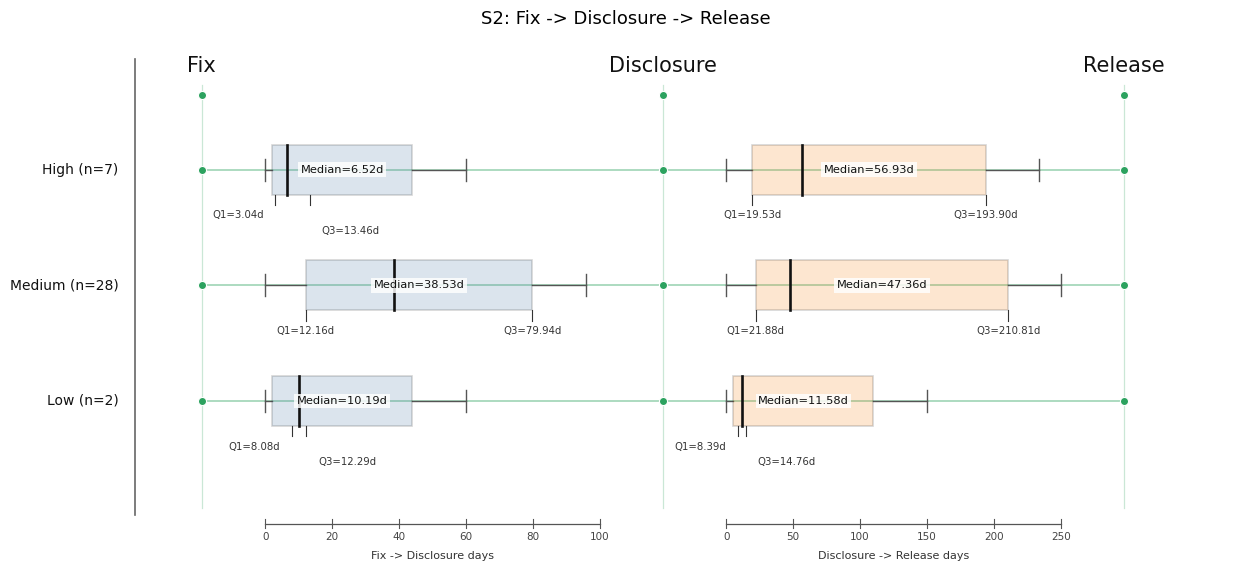

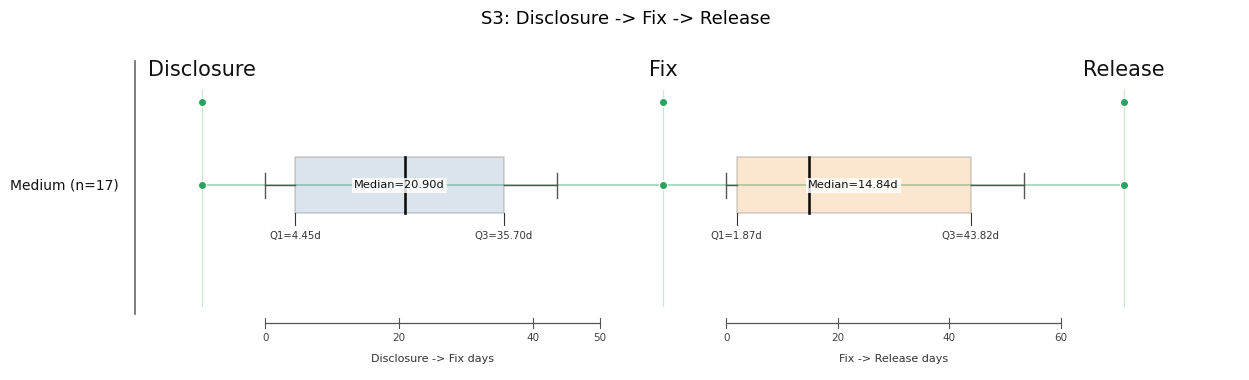

In [43]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

transition_pattern_titles = {
    'S1': 'S1: Fix -> Release -> Disclosure',
    'S2': 'S2: Fix -> Disclosure -> Release',
    'S3': 'S3: Disclosure -> Fix -> Release',
}
severity_levels = severity_order
minimum_plot_samples = 2


def pattern_severity_counts(df):
    count_df = (
        df
        .groupby(['Pattern', 'Severity'])
        .size()
        .rename('n')
        .reset_index()
    )
    severity_rank = {severity: index for index, severity in enumerate(severity_levels)}
    count_df['Severity rank'] = count_df['Severity'].map(severity_rank).fillna(99)
    return count_df.sort_values(['Pattern', 'Severity rank']).drop(columns='Severity rank')


silent_visual_sample_counts = pattern_severity_counts(silent_order_df)
silent_visual_excluded_groups = silent_visual_sample_counts[
    silent_visual_sample_counts['n'].lt(minimum_plot_samples)
].copy()

print(f'Excluded from visual because n < {minimum_plot_samples}:')
if silent_visual_excluded_groups.empty:
    print('None')
else:
    display(silent_visual_excluded_groups.reset_index(drop=True))

def round_up_to_10(value):
    if pd.isna(value) or value <= 0:
        return 10
    return int(np.ceil(value / 10) * 10)


def transition_stats(values):
    values = values.dropna()
    return {
        'n': len(values),
        'q1': values.quantile(0.25),
        'median': values.median(),
        'q3': values.quantile(0.75),
    }


def summary_axis_max(pattern_df, duration_column):
    rows = []
    for severity, group in pattern_df.groupby('Severity'):
        stats = transition_stats(group[duration_column])
        rows.append(stats)

    stats_df = pd.DataFrame(rows)
    if stats_df.empty:
        return 10

    # Use groups with n>1 when available, so single extreme categories do not shrink all boxes.
    base_df = stats_df[stats_df['n'].gt(1)].copy()
    if base_df.empty:
        base_df = stats_df

    visible_max = max(base_df['q3'].max(), base_df['median'].max())
    return round_up_to_10(visible_max * 1.15)


def local_axis_position_linear(value, start_x, end_x, axis_max):
    if pd.isna(value) or axis_max <= 0:
        return start_x
    fraction = min(max(value / axis_max, 0), 1)
    return start_x + fraction * (end_x - start_x)


def rounded_tick_values(axis_max):
    if axis_max <= 40:
        step = 10
    elif axis_max <= 100:
        step = 20
    elif axis_max <= 250:
        step = 50
    elif axis_max <= 500:
        step = 100
    else:
        step = 200

    ticks = list(range(0, int(axis_max) + 1, step))
    if ticks[-1] != axis_max:
        ticks.append(axis_max)
    return sorted(set(ticks))


def draw_rounded_local_axis(ax, start_x, end_x, y, axis_max, label):
    ax.plot([start_x, end_x], [y, y], color='#555555', linewidth=0.9, zorder=1)

    for tick_value in rounded_tick_values(axis_max):
        tick_x = local_axis_position_linear(tick_value, start_x, end_x, axis_max)
        ax.plot([tick_x, tick_x], [y - 0.05, y + 0.05], color='#555555', linewidth=0.8, zorder=1)
        ax.text(
            tick_x,
            y - 0.10,
            f'{tick_value}',
            ha='center',
            va='top',
            fontsize=7.5,
            color='#444444',
        )

    ax.text(
        (start_x + end_x) / 2,
        y - 0.32,
        f'{label} days',
        ha='center',
        va='top',
        fontsize=8,
        color='#333333',
    )


def draw_readable_boxplot_on_axis(ax, start_x, end_x, y, height, values, color, axis_max):
    stats = transition_stats(values)
    q1_x = local_axis_position_linear(stats['q1'], start_x, end_x, axis_max)
    median_x = local_axis_position_linear(stats['median'], start_x, end_x, axis_max)
    q3_x = local_axis_position_linear(stats['q3'], start_x, end_x, axis_max)

    axis_width = end_x - start_x
    min_box_width = axis_width * 0.42
    raw_left = min(q1_x, q3_x)
    raw_right = max(q1_x, q3_x)
    raw_width = raw_right - raw_left

    if raw_width < min_box_width:
        center_x = median_x
        left_x = center_x - min_box_width / 2
        right_x = center_x + min_box_width / 2
    else:
        left_x = raw_left
        right_x = raw_right

    left_x = max(left_x, start_x + axis_width * 0.02)
    right_x = min(right_x, end_x - axis_width * 0.02)
    if right_x - left_x < min_box_width:
        if left_x <= start_x + axis_width * 0.02:
            right_x = left_x + min_box_width
        else:
            left_x = right_x - min_box_width

    box = Rectangle(
        (left_x, y - height / 2),
        right_x - left_x,
        height,
        facecolor=color,
        edgecolor='#333333',
        linewidth=1.2,
        alpha=0.20,
        zorder=3,
    )
    ax.add_patch(box)

    median_x = min(max(median_x, left_x), right_x)
    ax.plot(
        [median_x, median_x],
        [y - height / 2, y + height / 2],
        color='#111111',
        linewidth=1.9,
        zorder=4,
    )

    whisker_left = max(start_x, left_x - axis_width * 0.16)
    whisker_right = min(end_x, right_x + axis_width * 0.16)
    ax.plot([whisker_left, left_x], [y, y], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([right_x, whisker_right], [y, y], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([whisker_left, whisker_left], [y - height * 0.22, y + height * 0.22], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([whisker_right, whisker_right], [y - height * 0.22, y + height * 0.22], color='#555555', linewidth=1.0, zorder=2)

    ax.text(
        (left_x + right_x) / 2,
        y,
        f'Median={stats["median"]:.2f}d',
        ha='center',
        va='center',
        fontsize=8.2,
        color='#111111',
        bbox={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.82,
            'pad': 1.6,
        },
        zorder=6,
    )

    # Q1 and Q3 are labeled outside the box at their mapped positions on the transition axis.
    # When Q1 and Q3 are close, stagger and nudge labels so both remain readable.
    ax.plot([q1_x, q1_x], [y - height / 2, y - height / 2 - 0.12], color='#333333', linewidth=0.8, zorder=4)
    ax.plot([q3_x, q3_x], [y - height / 2, y - height / 2 - 0.12], color='#333333', linewidth=0.8, zorder=4)

    label_base_y = y - height / 2 - 0.18
    close_labels = abs(q3_x - q1_x) < axis_width * 0.18
    if close_labels:
        q1_label_x = q1_x - axis_width * 0.035
        q3_label_x = q3_x + axis_width * 0.035
        q1_label_y = label_base_y
        q3_label_y = label_base_y - 0.18
        q1_ha = 'right'
        q3_ha = 'left'
    else:
        q1_label_x = q1_x
        q3_label_x = q3_x
        q1_label_y = label_base_y
        q3_label_y = label_base_y
        q1_ha = 'center'
        q3_ha = 'center'

    ax.text(
        q1_label_x,
        q1_label_y,
        f'Q1={stats["q1"]:.2f}d',
        ha=q1_ha,
        va='top',
        fontsize=7.3,
        color='#333333',
        bbox={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.86,
            'pad': 0.9,
        },
        zorder=6,
    )
    ax.text(
        q3_label_x,
        q3_label_y,
        f'Q3={stats["q3"]:.2f}d',
        ha=q3_ha,
        va='top',
        fontsize=7.3,
        color='#333333',
        bbox={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.86,
            'pad': 0.9,
        },
        zorder=6,
    )


def plot_stage_aligned_fixed_boxes_with_axes(pattern):
    pattern_df = silent_order_df[silent_order_df['Pattern'].eq(pattern)].copy()
    stages = [
        pattern_df['First'].iloc[0],
        pattern_df['Second'].iloc[0],
        pattern_df['Third'].iloc[0],
    ]
    severity_counts = pattern_df['Severity'].value_counts().to_dict()
    present_severities = [
        severity for severity in severity_levels
        if severity_counts.get(severity, 0) >= minimum_plot_samples
    ]
    pattern_df = pattern_df[pattern_df['Severity'].isin(present_severities)].copy()

    if not present_severities:
        print(f'Skipping {pattern}: no severity groups with n >= {minimum_plot_samples}.')
        return

    first_axis_max = summary_axis_max(pattern_df, 'Days: First -> Second')
    second_axis_max = summary_axis_max(pattern_df, 'Days: Second -> Third')

    row_gap = 1.34
    bottom_row_y = 1.72
    y_positions = {
        severity: bottom_row_y + row_gap * (len(present_severities) - index - 1)
        for index, severity in enumerate(present_severities)
    }

    fig_height = max(3.9, 1.15 * len(present_severities) + 2.4)
    fig, ax = plt.subplots(figsize=(12.8, fig_height))

    stage_x = [1.0, 5.0, 9.0]
    first_axis = (stage_x[0] + 0.55, stage_x[1] - 0.55)
    second_axis = (stage_x[1] + 0.55, stage_x[2] - 0.55)

    header_y = max(y_positions.values()) + 1.08
    axis_y = 0.30
    guide_color = '#2ca25f'

    for x, stage in zip(stage_x, stages):
        ax.text(
            x,
            header_y,
            stage,
            ha='center',
            va='bottom',
            fontsize=15,
            color='#111111',
        )
        ax.plot([x, x], [axis_y + 0.18, header_y - 0.10], color=guide_color, linewidth=0.9, alpha=0.25, zorder=0)
        ax.scatter([x], [header_y - 0.22], s=34, color=guide_color, edgecolor='white', linewidth=0.8, zorder=5)

    draw_rounded_local_axis(
        ax, first_axis[0], first_axis[1], axis_y, first_axis_max, f'{stages[0]} -> {stages[1]}'
    )
    draw_rounded_local_axis(
        ax, second_axis[0], second_axis[1], axis_y, second_axis_max, f'{stages[1]} -> {stages[2]}'
    )

    for severity in present_severities:
        severity_df = pattern_df[pattern_df['Severity'].eq(severity)].copy()
        y = y_positions[severity]

        ax.plot(stage_x, [y] * len(stage_x), color=guide_color, linewidth=1.1, alpha=0.50, zorder=1)
        ax.scatter(stage_x, [y] * len(stage_x), s=34, color=guide_color, edgecolor='white', linewidth=0.8, zorder=5)

        draw_readable_boxplot_on_axis(
            ax, first_axis[0], first_axis[1], y, 0.58, severity_df['Days: First -> Second'], '#4c78a8', first_axis_max
        )
        draw_readable_boxplot_on_axis(
            ax, second_axis[0], second_axis[1], y, 0.58, severity_df['Days: Second -> Third'], '#f58518', second_axis_max
        )

        ax.text(
            0.28,
            y,
            f'{severity} (n={severity_counts[severity]})',
            ha='right',
            va='center',
            fontsize=10,
            color='#111111',
        )

    ax.plot([0.42, 0.42], [axis_y + 0.10, header_y + 0.2], color='#666666', linewidth=1.2)
    ax.set_xlim(-0.65, 10.0)
    ax.set_ylim(-0.18, header_y + 0.35)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(transition_pattern_titles[pattern], fontsize=13, pad=16)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for pattern in ['S1', 'S2', 'S3']:
    plot_stage_aligned_fixed_boxes_with_axes(pattern)